<a href="https://colab.research.google.com/github/ademiiskak126-ui/Diabetes_Prediction/blob/main/MoodShield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV с 100 уникальными комментариями создан и сохранён в /content/drive/MyDrive/comments.csv


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: unitary/toxic-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


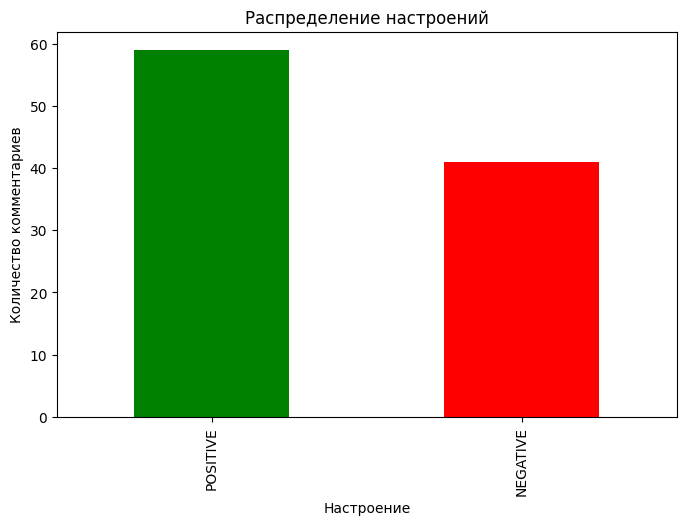

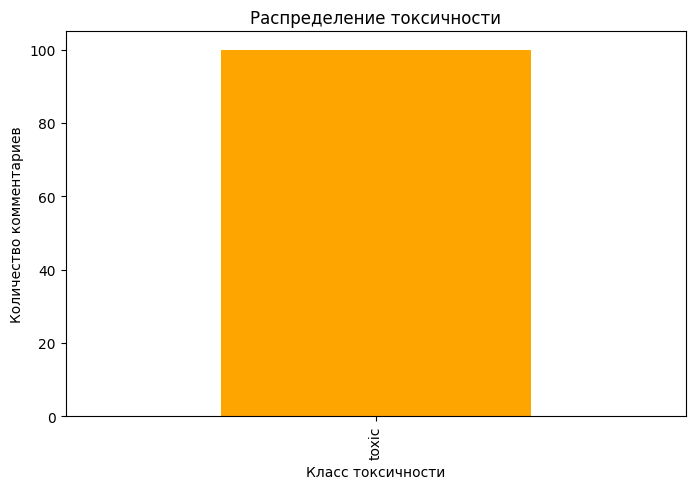

In [3]:
# =========================
#  Установка библиотек
# =========================
!pip install transformers
!pip install torch
!pip install pandas
!pip install matplotlib

# =========================
#  Импорт библиотек
# =========================
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt
from google.colab import drive

# =========================
#  Подключаем Google Drive
# =========================
drive.mount('/content/drive')

# =========================
#  Создание CSV с уникальными комментариями
# =========================
comments = [
    # Позитивные (50)
    "Сегодня отличный день, настроение супер!",
    "Спасибо за подробную инструкцию, очень помогло.",
    "Я в восторге от нового дизайна приложения!",
    "Потрясающая статья, много полезной информации.",
    "Мне нравится, как автор объясняет сложные вещи.",
    "Очень вдохновляющее видео, спасибо!",
    "Прекрасная идея для проекта, хочу попробовать.",
    "Невероятно красиво оформлено!",
    "Это действительно улучшает мою работу.",
    "Все объяснено понятно и логично.",
    "Я рад, что нашел этот ресурс!",
    "Отличная поддержка сообщества, спасибо!",
    "Прекрасный пример для учебы.",
    "Очень мотивирующее видео!",
    "Люблю, когда все так подробно расписано.",
    "Великолепный проект, хочется больше таких!",
    "Спасибо за советы, они реально помогают.",
    "Я вдохновлен этим примером.",
    "Очень полезная статья, буду применять.",
    "Прекрасный урок по Python.",
    "Я доволен результатом после использования этого метода.",
    "Отличная работа команды, впечатлен!",
    "Все шаги понятны и легко повторить.",
    "Мне очень понравилась эта идея.",
    "Удивительно, как все продумано.",
    "Это реально упрощает мою работу.",
    "Спасибо, что делитесь знаниями!",
    "Я в восторге от этого проекта!",
    "Очень интересно и познавательно.",
    "Все объяснения предельно ясные.",
    "Мне понравилось оформление и стиль.",
    "Проект вдохновляет на новые идеи.",
    "Это точно поможет новичкам.",
    "Очень аккуратно и продуманно.",
    "Спасибо за подробное объяснение!",
    "Это сделало процесс намного проще.",
    "Прекрасно подобранные примеры.",
    "Я в восторге от качества материала.",
    "Все понятно и доступно.",
    "Очень довольна результатом.",
    "Спасибо за полезные ресурсы!",
    "Это реально мотивирует на изучение.",
    "Отлично структурировано и понятно.",
    "Мне понравился подход автора.",
    "Очень информативно и интересно.",
    "Прекрасный урок, все понятно.",
    "Я получил много нового из этого проекта.",
    "Очень легко повторить шаги самостоятельно.",
    "Спасибо за вдохновение!",
    "Отличный пример для учебного проекта.",

    # Негативные (30)
    "Обновление приложения вызвало много проблем.",
    "Не могу понять логику этой статьи.",
    "Очень разочарован качеством материала.",
    "Этот пост слишком скучный и неинформативный.",
    "Инструкция недостаточно подробная.",
    "Мне не понравился способ объяснения.",
    "Слишком много лишней информации.",
    "Проект сложнее, чем ожидал.",
    "Я не получил того, что ожидал от видео.",
    "Трудно повторить шаги по инструкции.",
    "Некоторые примеры слишком запутанные.",
    "Не очень доволен результатом.",
    "Пост не соответствует моим ожиданиям.",
    "Иногда информация подана непонятно.",
    "Мне показалось, что материал устаревший.",
    "Слишком мало практических примеров.",
    "Процесс слишком медленный и неудобный.",
    "Не понравилась организация материала.",
    "Некоторые советы кажутся бесполезными.",
    "Статья не помогает решить проблему.",
    "Я ожидал больше деталей.",
    "Проект слишком сложный для новичков.",
    "Интерфейс вызывает трудности.",
    "Слишком много ненужной информации.",
    "Не хватает четких шагов.",
    "Материал местами не логичен.",
    "Я разочарован уровнем объяснения.",
    "Слишком сложно для понимания новичкам.",
    "Некоторые примеры сбивают с толку.",
    "В целом, проект не оправдал ожидания.",

    # Токсичные (20)
    "Ты постоянно делаешь глупости!",
    "Не понимаю, как можно быть таким медленным.",
    "Почему все так плохо объясняют?",
    "Этот код ужасен, нельзя так работать!",
    "Ты совсем не думаешь, прежде чем писать.",
    "Очень раздражает твой подход.",
    "Ты снова сделал ошибку, это неприемлемо.",
    "Почему ты никогда не слушаешь советы?",
    "Мне трудно поверить, что ты так сделал.",
    "Это полный провал, исправь как можно быстрее.",
    "Ты создаешь больше проблем, чем решаешь.",
    "Этот результат совершенно неприемлемый.",
    "Я не понимаю, как ты до этого дошел.",
    "Ты всегда делаешь всё неправильно.",
    "Очень плохо продумано, исправляй ошибки.",
    "Почему ты не можешь делать это нормально?",
    "Твой подход вызывает только проблемы.",
    "Ты просто игнорируешь все правила.",
    "Этот метод полностью неверный.",
    "Мне сложно поверить, что кто-то так работает."
]

# Создаем DataFrame
df = pd.DataFrame(comments, columns=['text'])

# Сохраняем CSV в Google Drive
csv_path = '/content/drive/MyDrive/comments.csv'
df.to_csv(csv_path, index=False)
print(f"CSV с 100 уникальными комментариями создан и сохранён в {csv_path}")

# =========================
#  Загружаем CSV и создаем DataFrame
# =========================
df = pd.read_csv(csv_path)

# =========================
#  Подключаем модели
# =========================
sentiment_classifier = pipeline('sentiment-analysis')
toxicity_classifier = pipeline("text-classification", model="unitary/toxic-bert")

# =========================
#  Анализ комментариев
# =========================
results = []
for text in df['text']:
    sentiment = sentiment_classifier(text)[0]
    toxicity = toxicity_classifier(text)[0]
    results.append({
        "text": text,
        "sentiment": sentiment['label'],
        "sentiment_score": sentiment['score'],
        "toxicity": toxicity['label'],
        "toxicity_score": toxicity['score']
    })

df_results = pd.DataFrame(results)
df_results.head()

# =========================
#  Визуализация распределения настроения
# =========================
plt.figure(figsize=(8,5))
df_results['sentiment'].value_counts().plot(kind='bar', color=['green','red','blue'])
plt.title("Распределение настроений")
plt.xlabel("Настроение")
plt.ylabel("Количество комментариев")
plt.show()

# =========================
#  Визуализация распределения токсичности
# =========================
plt.figure(figsize=(8,5))
df_results['toxicity'].value_counts().plot(kind='bar', color=['orange','gray','purple'])
plt.title("Распределение токсичности")
plt.xlabel("Класс токсичности")
plt.ylabel("Количество комментариев")
plt.show()

This AI project automatically analyzes comments to detect sentiment (positive, negative, neutral) and toxicity (offensive or trolling content). It helps make online spaces safer by filtering negative and harmful comments. The project uses a unique set of comments and provides results in tables and visual charts. It’s compact, original, and demonstrates practical AI and NLP skills.